In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import json


In [2]:
with open("./data/bbox.json", "r") as f:
    bbox = json.load(f)
min_lon, min_lat, max_lon, max_lat = [bbox["min_lon"], bbox["min_lat"], bbox["max_lon"], bbox["max_lat"]]

In [3]:
res = 0.125

filepath = "../../ARVI-IEO/IEO/DATA_ANALYSIS/unir_db_py/data_output/2005-2025.csv"
df = pd.read_csv(filepath, low_memory=False)
df["FechaCaptura"] = pd.to_datetime(df["FechaCaptura"], format="mixed")

mask_ds = xr.open_dataset(f"./data/processed/static/area_pesca_{res}.nc")

df.columns

Index(['IdCaptura', 'NombreBuque', 'CodigoBuque', 'ZonaFAO', 'ArteFAO',
       'FechaCaptura', 'Lat', 'Lon', 'NumOperaciones', 'TiempoPesca',
       'EspecieFAO', 'ValorMalla', 'Peso'],
      dtype='object')

In [4]:
df1 = df[["FechaCaptura","NombreBuque", "Lat", "Lon", "Peso", "TiempoPesca", "NumOperaciones", "EspecieFAO" ]] # Select only the necessary columns
df1= df1.dropna(subset=["Lat", "Lon", "TiempoPesca"])
df1[["Lat", "Lon"]] = df1[["Lat", "Lon"]].apply(lambda x: -abs(x)) #correccion de las posiciones

df1 = df1[
    (df1['Lon'] >= min_lon) & (df1['Lon'] <= max_lon) &
    (df1['Lat'] >= min_lat) & (df1['Lat'] <= max_lat)
    ] #solo datos del area de interés 
df1 = df1.dropna(subset=["Peso", "TiempoPesca"])

idx_dirigido = df1.groupby(['FechaCaptura', 'NombreBuque', 'Lat', 'Lon', 
                   'TiempoPesca', 'NumOperaciones'])['Peso'].idxmax()

df_dirigido = df1.loc[idx_dirigido, ['FechaCaptura', 'NombreBuque', 'Lat', 'Lon',
                            'TiempoPesca', 'NumOperaciones', 'EspecieFAO', "Peso"]].reset_index(drop=True)



df1_period = df1.copy()
df1_period['Fecha'] = df1_period['FechaCaptura'].dt.to_period('M').dt.to_timestamp()

df_dirigido_period = df_dirigido.copy()
df_dirigido_period['Fecha'] = df_dirigido_period['FechaCaptura'].dt.to_period('M').dt.to_timestamp()

df1_agg = (
    df1_period.groupby(["Fecha","EspecieFAO", "Lat", "Lon"], as_index=False)
      .agg(PesoTotal=('Peso', 'sum')))
df1_agg = df1_agg[df1_agg["EspecieFAO"].isin(["HKP", "SQA"])]

lances = df1[["FechaCaptura", "NombreBuque", "Lat", "Lon", "Peso", "TiempoPesca", "NumOperaciones"]].drop_duplicates()
lances['Fecha'] = lances['FechaCaptura'].dt.to_period('M').dt.to_timestamp()
effort = lances.groupby(["Fecha", "Lat", "Lon"]).agg(Horas=('TiempoPesca', 'sum')).reset_index()
effort["Horas"] = effort["Horas"].div(60)



#### Creación de grid

In [5]:

lat_grid = np.arange(min_lat, max_lat + res, res)
lon_grid = np.arange(min_lon, max_lon + res, res)

df1_agg['lat_bin'] = pd.cut(df1_agg['Lat'], bins=lat_grid, labels=lat_grid[:-1])
df1_agg['lon_bin'] = pd.cut(df1_agg['Lon'], bins=lon_grid, labels=lon_grid[:-1])

effort["lat_bin"] = pd.cut(effort["Lat"], bins=lat_grid, labels=lat_grid[:-1])
effort["lon_bin"] = pd.cut(effort["Lon"], bins=lon_grid, labels=lon_grid[:-1])

df1_grid = df1_agg.groupby(['Fecha', "lat_bin", "lon_bin", 'EspecieFAO'], observed=True).agg({"PesoTotal":"sum"}).reset_index()
effort_grid = effort.groupby(['Fecha', "lat_bin", "lon_bin"], observed=True)['Horas'].sum().reset_index() 


In [6]:
dsxr = (
    df1_grid
    .set_index(["Fecha", "lat_bin", "lon_bin", "EspecieFAO"]) #we define the xarray coordinates
    .to_xarray()
    .rename({"Fecha": "time", "lat_bin":"lat", "lon_bin":"lon", "EspecieFAO":"FAOspp"}))

dsxr = dsxr.reindex(lat=lat_grid, lon=lon_grid)
dsxr = dsxr.assign_coords(
    lat=dsxr["lat"].astype(str).astype(float),
    lon=dsxr["lon"].astype(str).astype(float))

dsxr_effort = (
    effort_grid
    .set_index(["Fecha", "lat_bin", "lon_bin"])
    .to_xarray()
    .rename({"Fecha": "time", "lat_bin":"lat", "lon_bin":"lon"})
    )
dsxr_effort = dsxr_effort.reindex(lat=lat_grid, lon=lon_grid)

dsxr_effort = dsxr_effort.assign_coords(
    lat=dsxr_effort["lat"].astype(str).astype(float),
    lon=dsxr_effort["lon"].astype(str).astype(float)
    )

In [7]:
valid = mask_ds["mask"]>0
dsxr_effort=dsxr_effort.where(valid)
dsxr = dsxr.where(valid)

In [8]:
dsxr["cpue_index"] = np.log1p(dsxr["PesoTotal"])-np.log1p(dsxr_effort["Horas"])
dsxr["CPUE"] = (dsxr["PesoTotal"]/dsxr_effort["Horas"]).where(dsxr_effort["Horas"]>0)

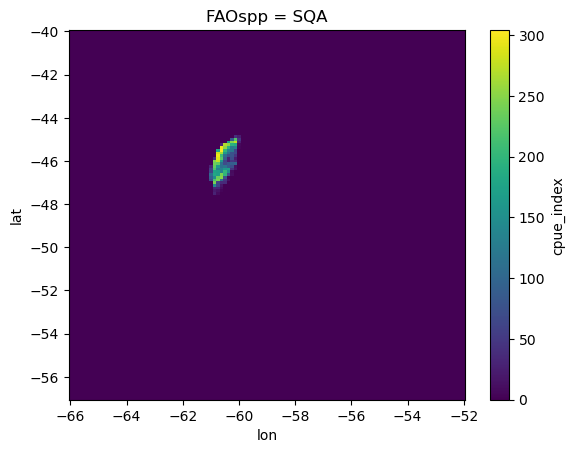

In [9]:
# dsxr_effort["Horas"].sum(dim="time").plot()
dsxr["cpue_index"].sel(FAOspp="SQA").sum(dim="time").plot()

In [10]:
effort_positive = dsxr_effort.where(dsxr_effort > 0)

pq_threshold = (
    effort_positive["Horas"]
    .groupby("time.year")
    .quantile(0.01, dim=("time", "lat", "lon"), skipna=True)
)

threshold_mask = dsxr_effort["Horas"].groupby("time.year") >= pq_threshold
mask = (
    (threshold_mask) & 
    (dsxr["CPUE"].notnull()) & 
    (dsxr_effort["Horas"].notnull())
)


# --- Apply mask to both datasets ---
# cells with effort below threshold become NaN

dsxr = dsxr.where(mask)
dsxr = dsxr.drop_vars("quantile")


full_time = pd.date_range(
    start="2009-01-01",
    end="2025-12-31",
    freq="MS"   # Month Start
)

dsxr = dsxr.reindex(time=full_time)
dsxr_effort = dsxr_effort.reindex(time=full_time)

#### Cpue classification ####
# 1. Compute the yearly median CPUE
yearly_median = dsxr["CPUE"].groupby("time.year").median(dim=("time", "lat", "lon"))

# 2. Classify: 2 if greater than median, 1 otherwise
cpue_class = xr.where(dsxr["CPUE"].groupby("time.year") > yearly_median, 2, 1)
cpue_class = cpue_class.where(mask)


# 4. Assign back to your dataset
dsxr["CPUE_class"] = cpue_class

dsxr.to_netcdf(f"./data/processed/targets/cpue_{res}.nc", mode="w")
dsxr_effort.to_netcdf(f"./data/processed/targets/esfuerzo_{res}.nc", mode="w")

yearly_median



<xarray.DataArray 'CPUE' (year: 17, FAOspp: 2)> Size: 272B
array([[ 82.75862069,   1.09468109],
       [110.17105263,   2.48188406],
       [100.67963905,   5.98958333],
       [143.13863823,   7.36967419],
       [172.67671233,  18.87579285],
       [115.22222222,  23.5202812 ],
       [137.45806355,  72.6       ],
       [152.62106463,   3.24233498],
       [128.89731243,   1.88940673],
       [127.26993112,   1.90632   ],
       [111.94790271,   0.87563039],
       [103.81488722,   5.83376755],
       [155.49940976,   5.91358402],
       [166.48181172,  37.51551812],
       [150.35860644,  14.25134379],
       [170.48757954,  11.84978404],
       [244.48998956,   3.93444792]])
Coordinates:
  * FAOspp   (FAOspp) object 16B 'HKP' 'SQA'
  * year     (year) int64 136B 2009 2010 2011 2012 2013 ... 2022 2023 2024 2025

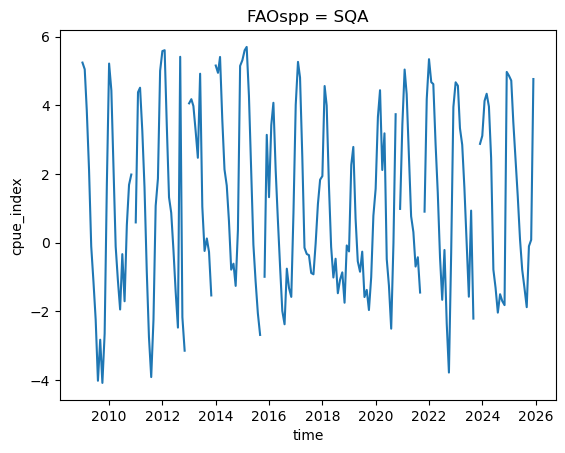

In [12]:
dsxr["cpue_index"].sel(FAOspp="SQA").mean(dim=("lat", "lon")).plot()